In [15]:
!pip install pulp

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/microgrid datasets data')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, value, PULP_CBC_CMD
import time

class BaselineModels():
  def __init__(self, data, num_days, battery_max):
    super(BaselineModels, self).__init__()
    # no of hours to simulate
    self.num_hours = 24 * num_days
    self.current_hour = 0
    self.daily_grid_use=0

    # store all necessary data for Rye Microgrid
    self.data = data

    # setup battery
    self.battery_max = battery_max
    self.battery_power = 0.5 * self.battery_max
    self.max_discharge = battery_max
    self.max_charge = battery_max

    self.total_load=sum(np.array(self.data['consumption'])[:self.num_hours])

    #left over load after renewable energy has been consumed --> positive means
    #not all consumption is satisfied, negative means extra energy.
    if 'wind_production' in self.data.columns:
      self.load=(np.array(self.data['consumption'])[:self.num_hours]
              -np.array(self.data['pv_production'])[:self.num_hours]
              -np.array(self.data['wind_production'])[:self.num_hours])
    else:
      self.load=(np.array(self.data['consumption'])[:self.num_hours]
              -np.array(self.data['pv_production'])[:self.num_hours])


    #hourly price
    self.price=np.array(self.data['spot_market_price'])[:self.num_hours]

  def step(self, action):
        """
        Actions:
        0 = Charge battery, 1 = Discharge battery,
        2 = Buy from grid, 3 = Sell to grid
        """
        cost_reward = 0
        grid_use = 0
        island=0

        load = self.load[self.current_hour]

        if action == 0:  # Charge
            charge_amount = min(self.max_charge, -load if load < 0 else 0)
            self.battery_power = min(self.battery_max, self.battery_power + charge_amount)
            island+=1

        elif action == 1:  # Discharge
            discharge_amount = min(self.max_discharge, load if load > 0 else 0)
            self.battery_power = max(0, self.battery_power - discharge_amount)
            island+=1

        elif action == 2:  # Buy
            cost_reward = -load * self.price[self.current_hour] if load > 0 else 0
            grid_use += load

        elif action == 3:  # Sell
            cost_reward = -load *self.price[self.current_hour] if load < 0 else 0

        self.current_hour += 1
        done = self.current_hour >= self.num_hours
        if self.current_hour%24==0:
          self.daily_grid_use=0

        self.daily_grid_use+=grid_use

        if 'wind_production' not in self.data.columns and self.daily_grid_use>40 and not done:
          self.price[self.current_hour]=0.10652

        reward={}
        reward['cost']=cost_reward
        reward['grid_use']=grid_use
        reward['island']=island

        return reward, done


  def reset(self):
    self.current_hour=0
    self.battery_power=0.5*self.battery_max

  def rule_based(self, visualization=False, full_outputs=False):
    rewards={
            'cost': [],
            'grid_use': [],
            'island': []
        }
    actions=[]
    charge=[]

    self.reset()
    done = False
    while not done:
      load = self.load[self.current_hour]

      if load <= 0:
        #Sell
        if self.battery_power == self.battery_max:
          action = 3
        #Charge
        else: action = 0
      else:
        #Discharge
        if self.battery_power > load and self.max_discharge>load:
          action = 1
        #Buy
        else:
            action = 2

      actions.append(action)
      reward, done=self.step(action)
      for key in reward.keys():
        rewards[key].append(reward[key])
      charge.append(self.battery_power)

    if visualization:
      self.visualize("Rule Based Algorithm", actions, rewards, charge)

    print(f"Profit: {float(sum(rewards['cost']))}")
    print(f"% Grid Energy Used: {float(sum(rewards['grid_use']))/self.total_load}")
    print(f"% Time in Island Mode: {float(sum(rewards['island']))/self.num_hours}")

    if full_outputs:
      return sum(rewards['cost']), sum(rewards['grid_use']), actions, rewards, charge
    else: return float(sum(rewards['cost'])), float(sum(rewards['grid_use']))



  def milp(self, visualization=False, full_outputs=False):
    actions = []
    rewards={
            'cost': [],
            'grid_use': [],
            'island': []
        }
    battery = []

    # Calculate number of weeks
    hours_per_week = 24 * 7
    num_iterations = (self.num_hours + hours_per_week - 1) // hours_per_week

    self.reset()  # Initialize battery state

    for week in range(num_iterations):
        start_time=time.time()

        prob = LpProblem(f"MILP_Week_{week}", LpMaximize)


        start_idx = week * hours_per_week
        end_idx = min((week + 1) * hours_per_week, self.num_hours)
        iter_price = self.price[start_idx:end_idx]
        iter_load = self.load[start_idx:end_idx]
        T = len(iter_price)

        if T == 0:
            continue

        x_c = iter_price
        y_c = [-x for x in iter_price]

        # Define variables
        x = {t: LpVariable(f"x_{t}", lowBound=0) for t in range(T)}  # Sell
        xb = {t: LpVariable(f"xb_{t}", cat="Binary") for t in range(T)}
        xa = {t: LpVariable(f"xa_{t}", lowBound=0) for t in range(T)}

        y = {t: LpVariable(f"y_{t}", lowBound=0) for t in range(T)}  # Buy
        yb = {t: LpVariable(f"yb_{t}", cat="Binary") for t in range(T)}
        ya = {t: LpVariable(f"ya_{t}", lowBound=0) for t in range(T)}

        z = {t: LpVariable(f"z_{t}", 0, self.max_charge) for t in range(T)}  # Charge
        zb = {t: LpVariable(f"zb_{t}", cat="Binary") for t in range(T)}
        za = {t: LpVariable(f"za_{t}", lowBound=0) for t in range(T)}

        w = {t: LpVariable(f"w_{t}", 0, self.max_discharge) for t in range(T)}  # Discharge
        wb = {t: LpVariable(f"wb_{t}", cat="Binary") for t in range(T)}
        wa = {t: LpVariable(f"wa_{t}", lowBound=0) for t in range(T)}

        C = {t: LpVariable(f"c_{t}", 0.2*self.battery_max, self.battery_max) for t in range(T)}  # Battery

        M = max(self.battery_max, max(abs(min(iter_load)), max(iter_load))) * 2

        # Objective
        prob += lpSum(x_c[t] * xa[t] + y_c[t] * ya[t] for t in range(T))

        # Constraints
        prob += C[0] == self.battery_power

        for t in range(T):

            prob += -xa[t] + ya[t] - za[t] + wa[t] == iter_load[t]

            prob += xb[t] + yb[t] + zb[t] + wb[t] <= 1

            prob += C[t] <= self.battery_max
            prob += C[t] >= 0

            # State of charge
            if t > 0:
                prob += C[t] == C[t-1] + za[t-1] - wa[t-1]

            # Linearization constraints
            for var, bin_var, act_var in [(x, xb, xa), (y, yb, ya), (z, zb, za), (w, wb, wa)]:
                prob += act_var[t] <= var[t]
                prob += act_var[t] >= var[t] - M * (1 - bin_var[t])
                prob += act_var[t] <= M * bin_var[t]

        # Solve
        status = prob.solve(PULP_CBC_CMD(msg=True, timeLimit=2400))
        print(f"Week {week} Solved -----{time.time()-start_time} Seconds-----")
        if status != 1:  # Check for optimal solution
            print(f"Warning: Week {week} optimization failed with status {status}")
            continue

        # Extract results
        week_actions = []
        for t in range(T):
            if value(zb[t]) >= 0.99:
                week_actions.append(0)  # Charge
            elif value(wb[t]) >= 0.99:
                week_actions.append(1)  # Discharge
            elif value(yb[t]) >= 0.99:
                week_actions.append(2)  # Buy
            elif value(xb[t]) >= 0.99:
                week_actions.append(3)  # Sell
            else:
                week_actions.append(4)  # Do nothing

        # Apply actions and track results
        for action in week_actions:
            reward, done = self.step(action)
            actions.append(action)
            for key in reward.keys():
              rewards[key].append(reward[key])
            battery.append(self.battery_power)  # Use actual battery state
            if done:
                break

        # Update initial state for next iteration
        if T > 0 and value(C[T-1]) is not None:
            self.battery_power = value(C[T-1])

    if visualization:
        self.visualize("MILP", actions, rewards, battery)

    if full_outputs:
        return sum(rewards['cost']), sum(rewards['grid_use']), actions, rewards, battery

    print(f"Profit: {float(sum(rewards['cost']))}")
    print(f"% Grid Energy Used: {float(sum(rewards['grid_use']))/self.total_load}")
    print(f"% Time in Island Mode: {float(sum(rewards['island']))/self.num_hours}")

    return float(sum(rewards['cost'])), float(sum(rewards['grid_use']))


  def visualize(self, baseline, actions, rewards, battery_power):
    print(baseline)

    time_steps = np.arange(len(rewards['cost']))
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel("Time Step")
    ax1.set_ylabel("Battery Charge", color='tab:blue')
    ax1.plot(time_steps, battery_power, label='Battery Charge', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel("Profit", color='tab:red')
    ax2.plot(time_steps, rewards['cost'], label='Profit', color='tab:red', linestyle='dashed')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10,5))

    ax.set_xlabel("Time Step")
    ax.set_ylabel("Grid Energy", color='tab:blue')
    ax.plot(time_steps, rewards['grid_use'], label='Grid Energy', color='tab:blue')


    fig.tight_layout()
    plt.show()

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel("Time Step")
    ax1.set_ylabel("Actions", color='tab:blue')
    ax1.scatter(time_steps, actions, label='Actions', color='tab:purple')
    ax1.tick_params(axis='y', labelcolor='tab:purple')

    fig.tight_layout()
    plt.show()


#Rye Microgrid

In [18]:
rye_test = pd.read_csv('test.csv')
rye_train = pd.read_csv("train.csv")

In [19]:
df1 = rye_test.copy()
df2 = rye_train.copy()
df1['time'] = pd.to_datetime(df1['time'])
df2['time'] = pd.to_datetime(df2['time'])

# Create common key based on month, day, hour, and minute
df1['match_key'] = df1['time'].dt.strftime('%m-%d %H:%M')
df2['match_key'] = df2['time'].dt.strftime('%m-%d %H:%M')

# Filter df2 to rows that match df1's timestamps (ignoring year)
df2_matched = df2[df2['match_key'].isin(df1['match_key'])]

# Drop the helper column
df1.drop(columns='match_key', inplace=True)
df2_matched.drop(columns='match_key', inplace=True)
rye_train_rel = df2_matched.reset_index(drop=True)

/tmp/ipython-input-19-1130517373.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_matched.drop(columns='match_key', inplace=True)


In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Columns to scale
cols_to_scale = ['consumption']

# Scale Test's Min/Max to that of Train
scaler = MinMaxScaler()
rye_test[cols_to_scale] = scaler.fit_transform(rye_test[cols_to_scale])
scaler = MinMaxScaler()
scaler.fit(rye_train_rel[cols_to_scale])
rye_test[cols_to_scale] = scaler.inverse_transform(rye_test[cols_to_scale])

Total Num Weeks 5
Week 0 Solved -----4.001277208328247 Seconds-----
Week 1 Solved -----2400.6436944007874 Seconds-----
Week 2 Solved -----7.686345815658569 Seconds-----
Week 3 Solved -----4.0600807666778564 Seconds-----
Week 4 Solved -----28.58595895767212 Seconds-----
MILP


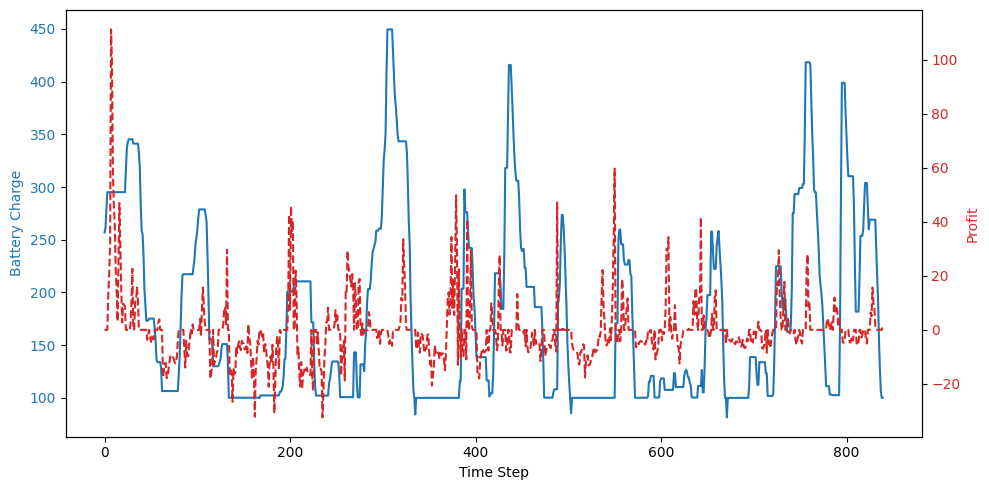

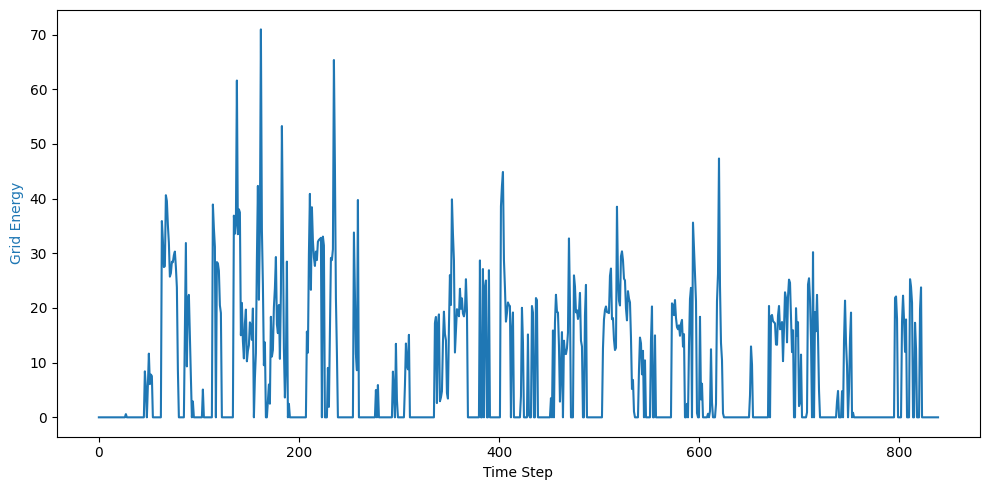

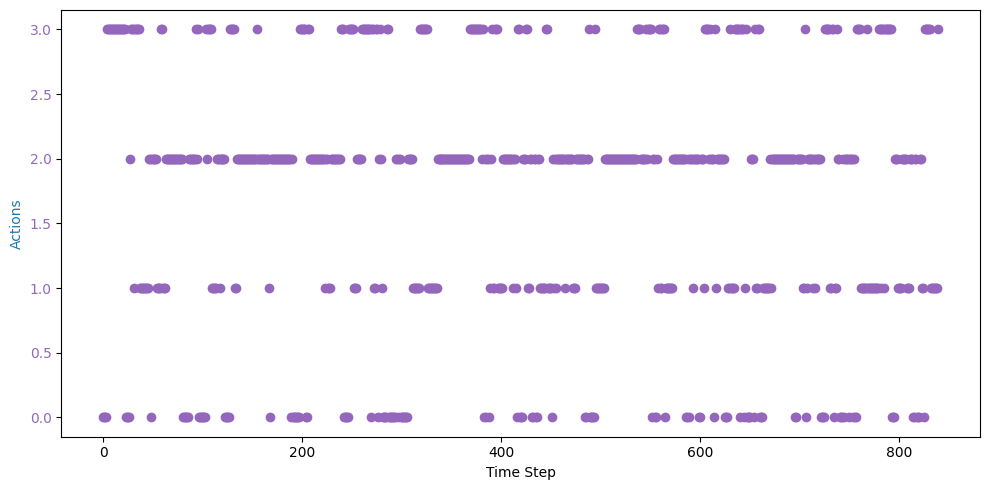

Profit: -209.37259368006644
% Grid Energy Used: 0.31963992358381427
% Time in Island Mode: 0.35119047619047616

Rule Based Algorithm


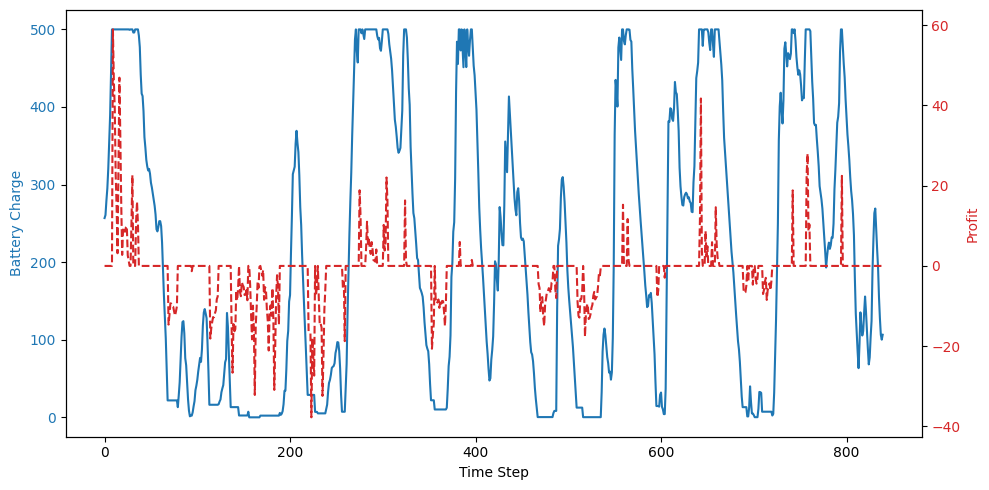

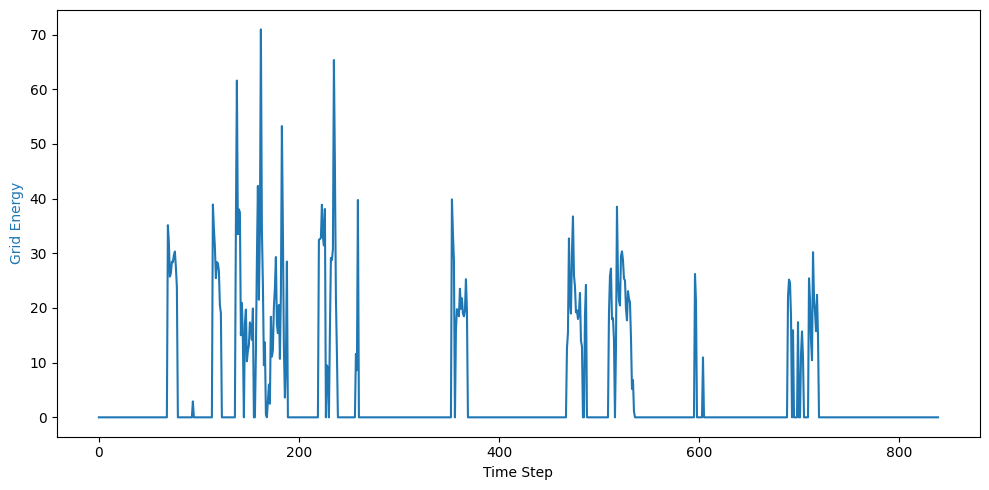

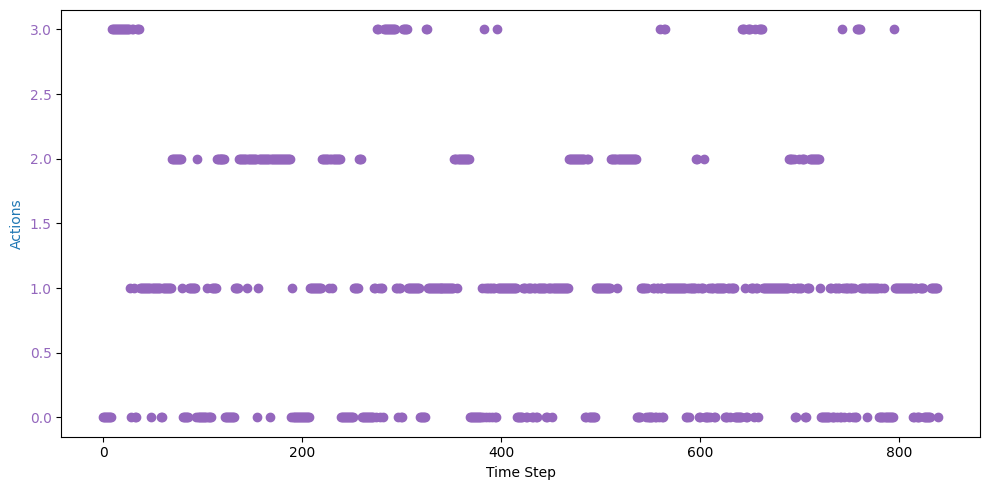

Profit: -839.1149419211614
% Grid Energy Used: 0.17129460031780172
% Time in Island Mode: 0.7214285714285714



In [29]:
test=BaselineModels(rye_test, len(rye_test)//(24), 500)
print(f"Total Num Weeks {len(rye_test)//(24*7)}")
test.milp(visualization=True)
print()
test.rule_based(visualization=True)
print()

In [22]:
print(sum(rye_test.iloc[:24*(len(rye_test)//24)]['consumption']))

22237.32137222327


#Lac Megantic

Total Num Weeks 4
Week 0 Solved -----0.18447589874267578 Seconds-----
Week 1 Solved -----0.19303178787231445 Seconds-----
Week 2 Solved -----0.18367767333984375 Seconds-----
Week 3 Solved -----0.18032598495483398 Seconds-----
MILP


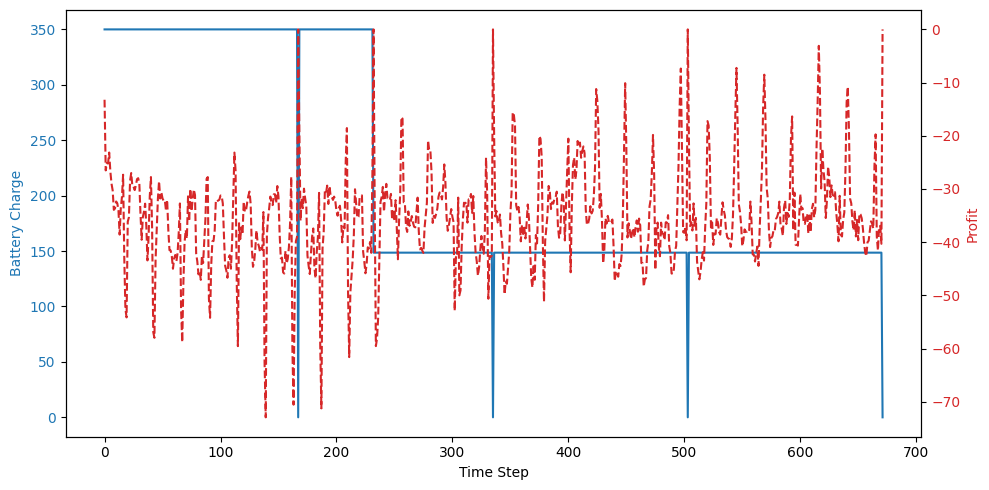

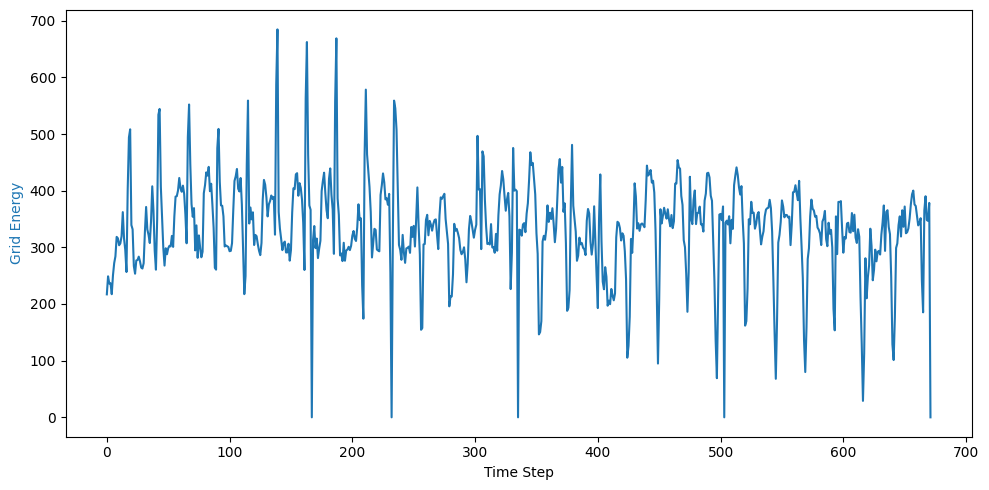

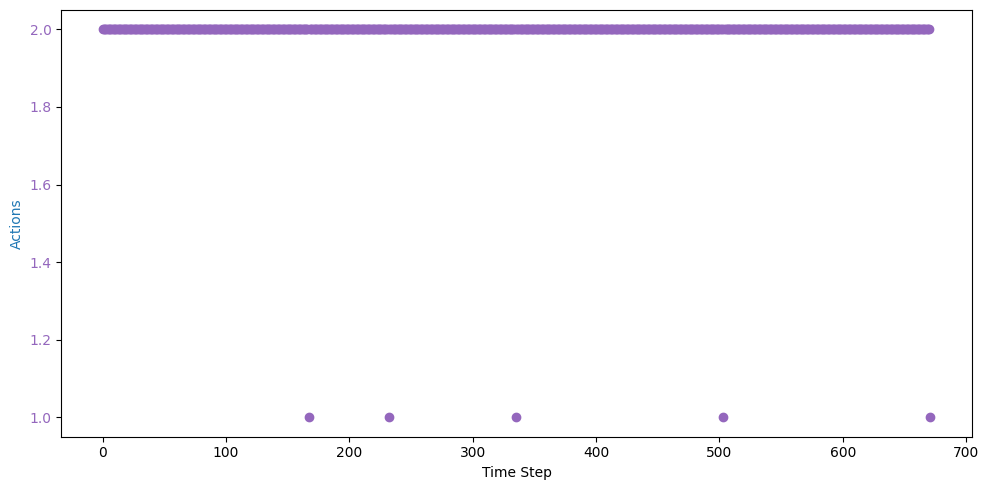

Profit: -23829.4287094424
% Grid Energy Used: 0.8827021724952199
% Time in Island Mode: 0.00744047619047619

Rule Based Algorithm


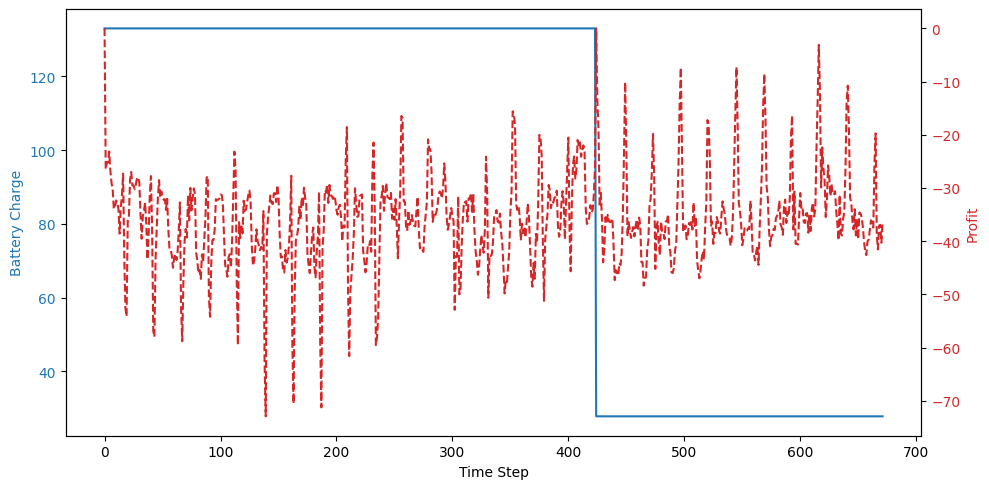

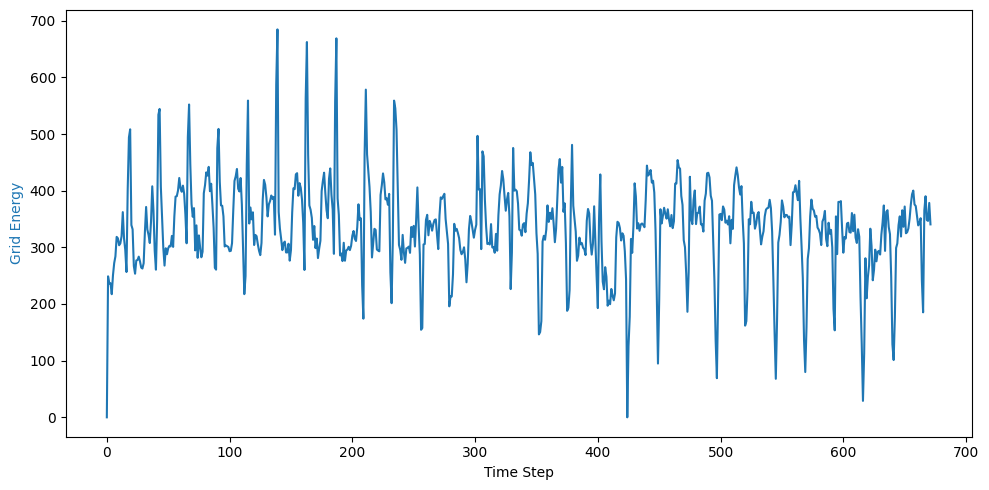

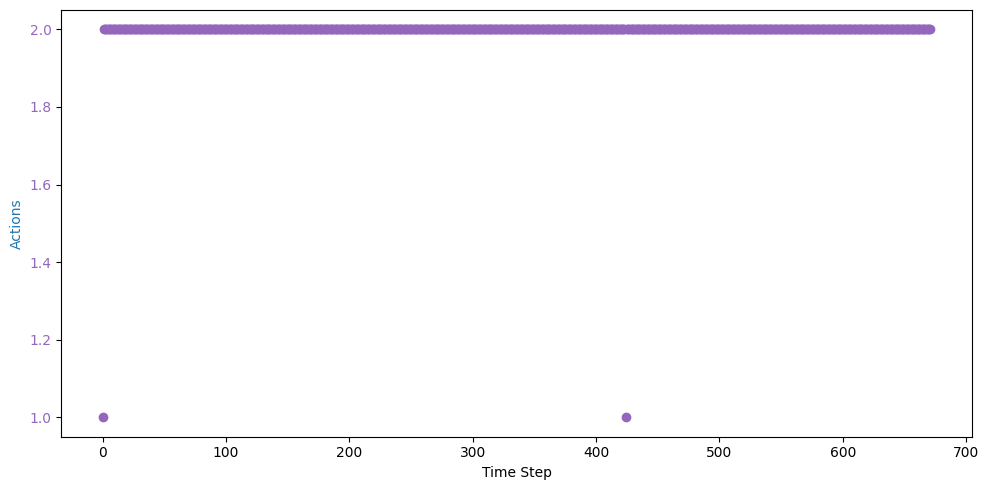

Profit: -24024.44010915781
% Grid Energy Used: 0.8878799874495258
% Time in Island Mode: 0.002976190476190476



In [23]:
data = pd.read_csv("LacMeganticDataTest.csv")
data['spot_market_price']=.06095
baselines=BaselineModels(data, len(data)//24, 700)
print(f"Total Num Weeks {31//7}")
baselines.milp(visualization=True)
print()
baselines.rule_based(visualization=True)
print()
#baselines.non_sliding_milp(visualization=True)

#Mesa De Sol

In [24]:
data=pd.read_csv('merged.csv')
data.head()

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,HOEP,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
0,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-13.966667,...,482.000000,59.964667,59.965667,21.99,5.49,10.237898,58.815450,81.960300,231.492200,7.011111
1,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-15.033333,...,482.333333,59.987667,59.986001,21.99,5.50,9.903779,59.171067,82.660450,231.314867,6.934259
2,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-15.000000,...,482.333333,59.999000,59.997334,21.99,5.51,9.569660,59.526683,83.360600,231.137533,6.857407
3,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-15.066667,...,482.200000,59.978667,59.978000,21.99,5.55,9.870432,59.882300,84.060750,230.960200,6.780556
4,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-14.600000,...,483.000000,59.999333,59.999333,21.99,5.59,10.171204,60.317400,83.788733,231.026067,6.703704


In [25]:
data['consumption']=data['Critical_Power_Load']+data['Essential_Power_Load']+data['Non_Critical_Power_Load']
data['pv_production']=data['PVPCS_Active_Power']
data['wind_production']=data['Wind_Power']
data['spot_market_price']=data['HOEP']
data=data[['consumption', 'pv_production', 'wind_production', 'spot_market_price']]

In [26]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, value, PULP_CBC_CMD
import time

class BaselineModels():
  def __init__(self, data, num_days, battery_max):
    super(BaselineModels, self).__init__()
    # no of hours to simulate
    self.num_steps = 24 * num_days * 12
    self.current_step = 0

    # store all necessary data for Rye Microgrid
    self.data = data

    # setup battery
    self.battery_max = battery_max
    self.battery_power = 0.5 * self.battery_max
    self.max_discharge = battery_max
    self.max_charge = battery_max
    self.max_generator = 94.8333
    self.max_fuel_cell = 38
    self.generator_price=0.01
    self.fuel_cell_price=0.01

    #left over load after renewable energy has been consumed --> positive means
    #not all consumption is satisfied, negative means extra energy.
    self.load= (np.array(self.data['consumption'])[:self.num_steps]
              -np.array(self.data['pv_production'])[:self.num_steps]
              -np.array(self.data['wind_production'])[:self.num_steps])

    self.total_load=sum(np.array(self.data['consumption'])[:self.num_steps])
    #hourly price
    self.price=np.array(self.data['spot_market_price'])[:self.num_steps]

  def step(self, action, generator, fuel_cell):
        """
        Actions:
        0 = Charge battery, 1 = Discharge battery,
        2 = Buy from grid, 3 = Sell to grid
        """

        cost_reward = 0
        grid_use = 0
        island=0
        load = self.load[self.current_step]-generator-fuel_cell
        cost_reward += -self.fuel_cell_price*fuel_cell -self.generator_price*generator

        if action == 0:  # Charge
            charge_amount = min(self.max_charge, -load if load < 0 else 0)
            self.battery_power = min(self.battery_max, self.battery_power + charge_amount)
            island+=1

        elif action == 1:  # Discharge
            discharge_amount = min(self.max_discharge, load if load > 0 else 0)
            self.battery_power = max(0, self.battery_power - discharge_amount)
            island+=1

        elif action == 2:  # Buy
            cost_reward += -load * self.price[self.current_step] if load > 0 else 0
            grid_use += load

        elif action == 3:  # Sell
            cost_reward = -load *self.price[self.current_step] if load < 0 else 0

        self.current_step += 1
        done = self.current_step >= self.num_steps

        reward={}
        reward['cost']=cost_reward
        reward['grid_use']=grid_use
        reward['fuel_cell']=fuel_cell
        reward['generator']=generator
        reward['island']=island

        return reward, done


  def reset(self):
    self.current_step=0
    self.battery_power=0.5*self.battery_max

  def rule_based(self, visualization=False, full_outputs=False):
    rewards={
            'cost': [],
            'grid_use': [],
            'fuel_cell': [],
            'generator': [],
            'island': []
        }

    actions=[]
    charge=[]

    self.reset()
    done = False
    while not done:
      load = self.load[self.current_step]

      #satisfy with generator
      generator = min(self.max_generator, load)
      load-=generator

      #satisfy with fuel_cell
      fuel_cell = min(self.max_fuel_cell, load)
      load-=fuel_cell

      if load <= 0:
        #Sell
        if self.battery_power == self.battery_max:
          action = 3
        #Charge
        else: action = 0
      else:
        #Discharge
        if self.battery_power > load and self.max_discharge>load:
          action = 1
        #Buy
        else:
            action = 2

      reward, done=self.step(action, generator, fuel_cell)
      for key in reward.keys():
          rewards[key].append(reward[key])




    print(f"Profit: {float(sum(rewards['cost']))}")
    print(f"Grid Energy % Used: {float(sum(rewards['grid_use']))/self.total_load}")
    print(f"Generator % Used: {float(sum(rewards['generator']))/self.total_load}")
    print(f"Fuel Cell % Used: {float(sum(rewards['fuel_cell']))/self.total_load}")
    print(f"% Time in Island Mode: {float(sum(rewards['island']))/self.num_steps}")



  def milp(self, visualization=False, full_outputs=False):
    actions = []
    rewards={
            'cost': [],
            'grid_use': [],
            'fuel_cell': [],
            'generator': [],
            'island': []
        }
    battery = []

    # Calculate number of weeks
    steps_per_week = 24 * 7 * 12
    num_iterations = (self.num_steps + steps_per_week - 1) // steps_per_week

    self.reset()  # Initialize battery state

    for week in range(num_iterations):
        start_time=time.time()

        prob = LpProblem(f"MILP_Week_{week}", LpMaximize)


        start_idx = week * steps_per_week
        end_idx = min((week + 1) * steps_per_week, self.num_steps)
        iter_price = self.price[start_idx:end_idx]
        iter_load = self.load[start_idx:end_idx]
        T = len(iter_price)

        if T == 0:
            continue

        x_c = iter_price
        y_c = [-x for x in iter_price]

        # Define variables
        x = {t: LpVariable(f"x_{t}", lowBound=0) for t in range(T)}  # Sell
        xb = {t: LpVariable(f"xb_{t}", cat="Binary") for t in range(T)}
        xa = {t: LpVariable(f"xa_{t}", lowBound=0) for t in range(T)}

        y = {t: LpVariable(f"y_{t}", lowBound=0) for t in range(T)}  # Buy
        yb = {t: LpVariable(f"yb_{t}", cat="Binary") for t in range(T)}
        ya = {t: LpVariable(f"ya_{t}", lowBound=0) for t in range(T)}

        z = {t: LpVariable(f"z_{t}", 0, self.max_charge) for t in range(T)}  # Charge
        zb = {t: LpVariable(f"zb_{t}", cat="Binary") for t in range(T)}
        za = {t: LpVariable(f"za_{t}", lowBound=0) for t in range(T)}

        w = {t: LpVariable(f"w_{t}", 0, self.max_discharge) for t in range(T)}  # Discharge
        wb = {t: LpVariable(f"wb_{t}", cat="Binary") for t in range(T)}
        wa = {t: LpVariable(f"wa_{t}", lowBound=0) for t in range(T)}

        C = {t: LpVariable(f"c_{t}", 0.2*self.battery_max, self.battery_max) for t in range(T)}  # Battery

        f = {t: LpVariable(f"f_{t}", lowBound=0, upBound=self.max_fuel_cell) for t in range(T)} #fuel cell

        g = {t: LpVariable(f"g_{t}", lowBound=0, upBound=self.max_generator) for t in range(T)} #generator

        M = max(self.battery_max, max(abs(min(iter_load)), max(iter_load))) * 2


        # Objective
        prob += lpSum(x_c[t] * xa[t] + y_c[t] * ya[t] - self.fuel_cell_price * f[t] - self.generator_price * g[t] for t in range(T))

        # Constraints
        prob += C[0] == self.battery_power

        for t in range(T):

            prob += -xa[t] + ya[t] - za[t] + wa[t] + f[t] + g[t] == iter_load[t]

            prob += xb[t] + yb[t] + zb[t] + wb[t] <= 1

            prob += C[t] <= self.battery_max
            prob += C[t] >= 0

            # State of charge
            if t > 0:
                prob += C[t] == C[t-1] + za[t-1] - wa[t-1]

            # Linearization constraints
            for var, bin_var, act_var in [(x, xb, xa), (y, yb, ya), (z, zb, za), (w, wb, wa)]:
                prob += act_var[t] <= var[t]
                prob += act_var[t] >= var[t] - M * (1 - bin_var[t])
                prob += act_var[t] <= M * bin_var[t]

        # Solve
        status = prob.solve(PULP_CBC_CMD(msg=True, timeLimit=120))
        print(f"Week {week} Solved -----{time.time()-start_time} Seconds-----")
        if status != 1:  # Check for optimal solution
            print(f"Warning: Week {week} optimization failed with status {status}")
            continue

        # Extract results
        week_actions = []

        for t in range(T):
            if value(zb[t]) >= 0.99:
                week_actions.append(0)  # Charge
            elif value(wb[t]) >= 0.99:
                week_actions.append(1)  # Discharge
            elif value(yb[t]) >= 0.99:
                week_actions.append(2)  # Buy
            elif value(xb[t]) >= 0.99:
                week_actions.append(3)  # Sell
            else:
                week_actions.append(4)  # Do nothing

        # Apply actions and track results
        for t in range(T):
            reward, done = self.step(week_actions[t], f[t].value(), g[t].value())
            actions.append(week_actions[t])
            for key in reward.keys():
              rewards[key].append(reward[key])
            battery.append(self.battery_power)  # Use actual battery state
            if done:
                break

        # Update initial state for next iteration
        if T > 0 and value(C[T-1]) is not None:
            self.battery_power = value(C[T-1])

    print(f"Profit: {float(sum(rewards['cost']))}")
    print(f"Grid Energy % Used: {float(sum(rewards['grid_use']))/self.total_load}")
    print(f"Generator % Used: {float(sum(rewards['generator']))/self.total_load}")
    print(f"Fuel Cell % Used: {float(sum(rewards['fuel_cell']))/self.total_load}")
    print(f"% Time in Island Mode: {float(sum(rewards['island']))/self.num_steps}")

In [14]:
baselines=BaselineModels(data, len(data)//24//12, 160)
print(f"Total Num Weeks {len(data)//24//12//7}")
baselines.milp(visualization=True)
print()
baselines.rule_based(visualization=True)
print()

Total Num Weeks 52
Week 0 Solved -----4.504301309585571 Seconds-----
Week 1 Solved -----3.6055727005004883 Seconds-----
Week 2 Solved -----3.172902822494507 Seconds-----
Week 3 Solved -----4.184887409210205 Seconds-----
Week 4 Solved -----4.101891040802002 Seconds-----
Week 5 Solved -----3.4191954135894775 Seconds-----
Week 6 Solved -----3.5150628089904785 Seconds-----
Week 7 Solved -----4.4710962772369385 Seconds-----
Week 8 Solved -----3.1691677570343018 Seconds-----
Week 9 Solved -----7.133277893066406 Seconds-----
Week 10 Solved -----8.327195405960083 Seconds-----
Week 11 Solved -----5.522863149642944 Seconds-----
Week 12 Solved -----6.517346143722534 Seconds-----
Week 13 Solved -----3.876070976257324 Seconds-----
Week 14 Solved -----3.2584712505340576 Seconds-----
Week 15 Solved -----4.481656789779663 Seconds-----
Week 16 Solved -----3.387315034866333 Seconds-----
Week 17 Solved -----3.0749330520629883 Seconds-----
Week 18 Solved -----3.161118268966675 Seconds-----
Week 19 Solved 